## Initialization

In [ ]:
# Use the reusable requirements helper module (utils/requirements_helper.py)
from utils.requirements_helper import ensure_requirements, export_requirements

# Default behavior: read ./requirements.txt and install any missing packages into
# the currently running Python (the notebook kernel). Run this cell first before
# running other cells that import project libraries.
ensure_requirements()

# Optional: to regenerate a pinned requirements file from the environment, run:
# export_requirements()  # writes a minimal pinned requirements.txt
# export_requirements(use_freeze=True)  # writes full pip freeze output

In [ ]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm, jarque_bera

### 1. Define the Assets and Date Range

In [ ]:
# Replace these with your chosen 5-10 assets!
ASSET_TICKERS = ['AAPL', 'MSFT', 'JPM', 'TSLA', 'SPY']
START_DATE = '2020-11-20'  # ~5 years prior to the context date

### 2. Download Data


In [ ]:
print("Starting data download...")
data = yf.download(ASSET_TICKERS, start=START_DATE)['Close']

### 3. Calculate Daily Log Returns

In [ ]:
# The log return is defined as: R_t = ln(P_t / P_{t-1})
log_returns = np.log(data / data.shift(1)).dropna()

print("\nData Download and Log Returns Calculation Complete.")
print(f"Period covered: {log_returns.index.min().date()} to {log_returns.index.max().date()}")

### 4. Price and Performance Charts

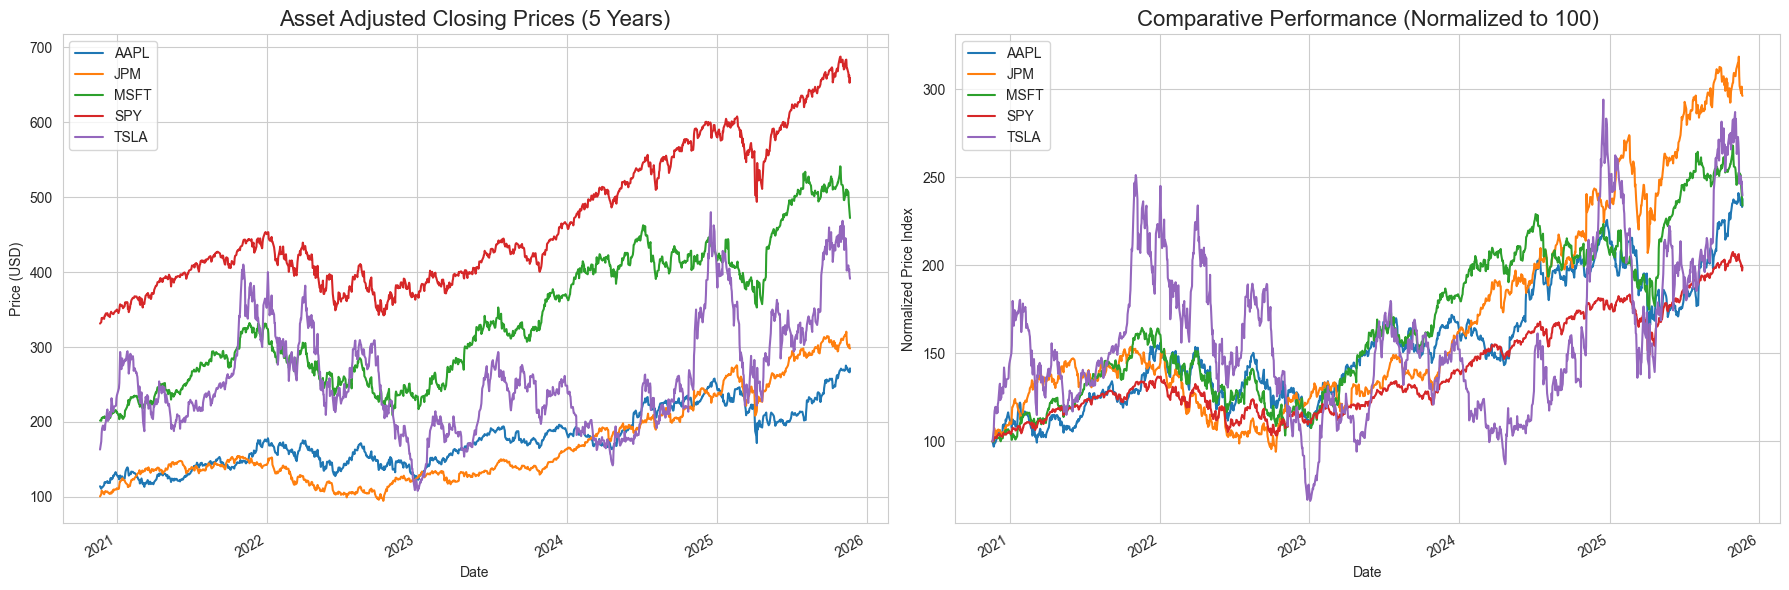

In [15]:
# Configure plotting style
sns.set_style("whitegrid")
plt.figure(figsize=(18, 6))

# --- Chart A: Price Time Series (Last 5 Years) ---
plt.subplot(1, 2, 1)
data.plot(ax=plt.gca(), legend=False)
plt.title('Asset Adjusted Closing Prices (5 Years)', fontsize=16)
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.legend(data.columns, loc='upper left')

# --- Chart B: Comparative Performance (Normalized to 100) ---
# Normalize the price series by dividing by the starting price and multiplying by 100
normalized_prices = data.div(data.iloc[0]) * 100

plt.subplot(1, 2, 2)
normalized_prices.plot(ax=plt.gca())
plt.title('Comparative Performance (Normalized to 100)', fontsize=16)
plt.ylabel('Normalized Price Index')
plt.xlabel('Date')
plt.legend(normalized_prices.columns, loc='upper left')
plt.tight_layout()
plt.show()

### 5.Histograms of Daily Returns

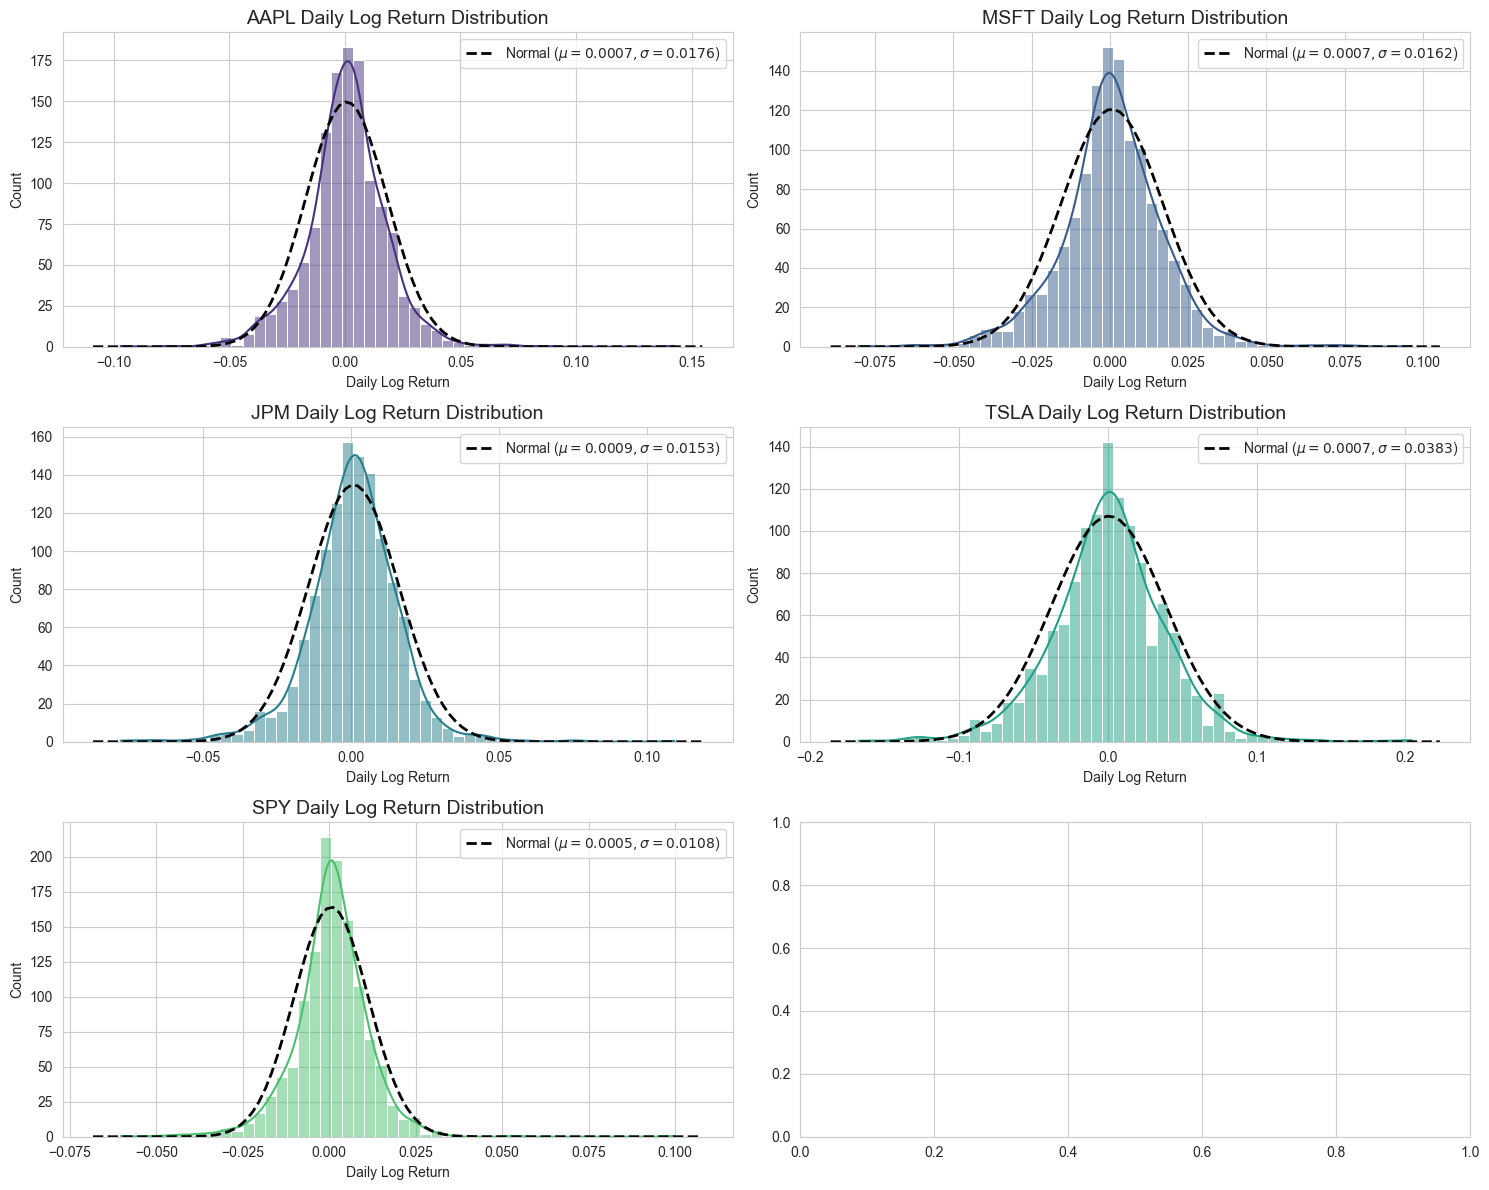

In [16]:
num_assets = len(ASSET_TICKERS)
fig, axes = plt.subplots(nrows=(num_assets + 1) // 2, ncols=2, figsize=(15, 4 * ((num_assets + 1) // 2)))

for i, ticker in enumerate(ASSET_TICKERS):
    row = i // 2
    col = i % 2
    
    # Calculate Mean and Std Dev for the Title
    mean_return = log_returns[ticker].mean()
    std_dev = log_returns[ticker].std()
    
    # Plot the histogram
    sns.histplot(log_returns[ticker].dropna(), bins=50, kde=True, ax=axes[row, col], 
                 color=sns.color_palette("viridis")[i % 6])
    
    # Add a normal distribution curve for comparison
    xmin, xmax = axes[row, col].get_xlim()
    x = np.linspace(xmin, xmax, 100)
    p = norm.pdf(x, mean_return, std_dev)
    
    # Scale the normal PDF to fit the histogram height
    scale_factor = len(log_returns[ticker]) * (xmax - xmin) / 50  # Approximation
    axes[row, col].plot(x, p * scale_factor, 'k--', linewidth=2, 
                        label=f'Normal ($\mu={mean_return:.4f}, \sigma={std_dev:.4f}$)')
    
    axes[row, col].set_title(f'{ticker} Daily Log Return Distribution', fontsize=14)
    axes[row, col].set_xlabel('Daily Log Return')
    axes[row, col].legend()

plt.tight_layout()
plt.show()

### 6. Comparative Statistics and Normality Check (1-Year Window)

In [17]:
# Filter returns for the last 1 year
one_year_ago = pd.to_datetime('today') - pd.DateOffset(years=1)
returns_1yr = log_returns[log_returns.index >= one_year_ago]

# --- Comparative Statistics ---
statistics = returns_1yr.agg(['mean', 'std', 'skew', 'kurtosis']).T
statistics.rename(columns={'mean': 'Mean Daily Return', 
                           'std': 'Daily Volatility (sigma_d)'}, inplace=True)

# Annualize Daily Volatility
# Assume 252 trading days per year for stocks/ETFs
statistics['Annual Volatility (sigma_a)'] = statistics['Daily Volatility (sigma_d)'] * np.sqrt(252)

# --- Normality Check (Jarque-Bera Test) ---
normality_results = {}
for ticker in ASSET_TICKERS:
    # Jarque-Bera Test returns (JB statistic, p-value)
    jb_test_result = jarque_bera(returns_1yr[ticker].dropna())
    p_value = jb_test_result[1]
    
    # H0: The data is normally distributed.
    # If p-value < 0.05, we reject H0.
    is_normal = 'No (Reject H0)' if p_value < 0.05 else 'Yes (Fail to Reject H0)'
    
    normality_results[ticker] = {
        'JB p-value': f'{p_value:.4f}',
        'Is Normal? (p<0.05)': is_normal
    }

normality_df = pd.DataFrame(normality_results).T

# Combine and print the results
final_stats = pd.concat([statistics, normality_df], axis=1)

print("### Comparative Statistics and Normality Check (1-Year Window) ###")
print("Note: The annual volatility (sigma_a) will be used for Black-Scholes.")
print("\nSTATISTICS:")
print(final_stats.to_markdown(floatfmt=".4f"))

### Comparative Statistics and Normality Check (1-Year Window) ###
Note: The annual volatility (sigma_a) will be used for Black-Scholes.

STATISTICS:
|      |   Mean Daily Return |   Daily Volatility (sigma_d) |    skew |   kurtosis |   Annual Volatility (sigma_a) |   JB p-value | Is Normal? (p<0.05)   |
|:-----|--------------------:|-----------------------------:|--------:|-----------:|------------------------------:|-------------:|:----------------------|
| AAPL |              0.0007 |                       0.0204 |  0.6526 |    11.5248 |                        0.3244 |       0.0000 | No (Reject H0)        |
| JPM  |              0.0008 |                       0.0153 | -0.7704 |     6.6396 |                        0.2436 |       0.0000 | No (Reject H0)        |
| MSFT |              0.0005 |                       0.0153 |  1.0510 |     8.8113 |                        0.2423 |       0.0000 | No (Reject H0)        |
| SPY  |              0.0005 |                       0.0123 |  1.0483 

### 7. Black-Scholes Option Pricing

In [18]:

# Define the Black-Scholes function for European Calls
def black_scholes_call(S, K, T, sigma, r=0, q=0):
    """
    Calculates the European Call option price using the Black-Scholes-Merton model.
    Assumes r (risk-free rate) and q (dividend yield) are zero as per prompt.
    
    Args:
        S (float): Current asset price (Spot Price)
        K (float): Strike Price
        T (float): Time to Expiration (in years)
        sigma (float): Annual Volatility
        r (float): Risk-free Rate (default 0)
        q (float): Dividend Yield (default 0)
        
    Returns:
        float: Call Option Price
    """
    
    # Calculate d1 and d2
    d1 = (np.log(S / K) + (r - q + sigma**2 / 2) * T) / (sigma * np.sqrt(T))
    d2 = d1 - sigma * np.sqrt(T)
    
    # Calculate the Call price
    call_price = (S * np.exp(-q * T) * norm.cdf(d1)) - \
                 (K * np.exp(-r * T) * norm.cdf(d2))
    
    return call_price

# --- Set Required Inputs ---
T = 1.0  # Time to Expiration = 1 year (matching the volatility window)
r = 0.0  # Risk-free rate = 0 (as per prompt)
q = 0.0  # Dividend yield = 0 (as per prompt)

# Get the Annual Volatility (sigma) and the last observed asset price (S)
option_prices = {}
last_prices = data.iloc[-1]

print("\n### Black-Scholes Option Pricing ###")

for ticker in ASSET_TICKERS:
    S = last_prices[ticker]  # Current Asset Price
    K = S                   # Strike Price = Last Observed Price
    sigma_a = final_stats.loc[ticker, 'Annual Volatility (sigma_a)']
    
    # Calculate the Call Price
    call_value = black_scholes_call(S, K, T, sigma_a, r=r, q=q)
    
    option_prices[ticker] = {
        'S (Last Price)': f'{S:.2f}',
        'K (Strike Price)': f'{K:.2f}',
        'T (Time to Exp.)': f'{T:.0f}',
        'Sigma (Annual Volatility)': f'{sigma_a:.4f}',
        'Call Option Price': f'{call_value:.4f}'
    }

option_df = pd.DataFrame(option_prices).T

print("\nOPTIONS PRICING (ATM Calls, T=1yr, r=q=0):")
print(option_df.to_markdown())

# Print conclusion for the notebook
print(f"\n--- Project Execution Complete ---")
print("The results provide the required graphs, statistics (1-year window), normality checks, and Black-Scholes option prices for at-the-money European Call options (K=S) with 1 year to expiry.")


### Black-Scholes Option Pricing ###

OPTIONS PRICING (ATM Calls, T=1yr, r=q=0):
|      |   S (Last Price) |   K (Strike Price) |   T (Time to Exp.) |   Sigma (Annual Volatility) |   Call Option Price |
|:-----|-----------------:|-------------------:|-------------------:|----------------------------:|--------------------:|
| AAPL |           271.49 |             271.49 |                  1 |                      0.3244 |             34.9782 |
| MSFT |           472.12 |             472.12 |                  1 |                      0.2423 |             45.5261 |
| JPM  |           298.02 |             298.02 |                  1 |                      0.2436 |             28.8894 |
| TSLA |           391.09 |             391.09 |                  1 |                      0.6513 |             99.8447 |
| SPY  |           659.03 |             659.03 |                  1 |                      0.1958 |             51.3892 |

--- Project Execution Complete ---
The results provide the requ